# Loading DAta

In [12]:
import pandas as l;'pd
df = pd.read_csv(r"C:\Users\AFAQE\Desktop\HR_Project\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [21]:
df.shape

(1470, 32)

In [31]:
df.shape
df.info()
df['attrition'].value_counts(normalize=True).mul(100).round(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       1470 non-null   int64 
 1   attrition                 1470 non-null   object
 2   businesstravel            1470 non-null   object
 3   dailyrate                 1470 non-null   int64 
 4   department                1470 non-null   object
 5   distancefromhome          1470 non-null   int64 
 6   education                 1470 non-null   int64 
 7   educationfield            1470 non-null   object
 8   employeenumber            1470 non-null   int64 
 9   environmentsatisfaction   1470 non-null   int64 
 10  gender                    1470 non-null   object
 11  hourlyrate                1470 non-null   int64 
 12  jobinvolvement            1470 non-null   int64 
 13  joblevel                  1470 non-null   int64 
 14  jobrole                 

attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64

In [20]:
df = df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours'])


In [22]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.head(10)

,age,attrition,businesstravel,dailyrate,department,distancefromhome,education,educationfield,employeenumber,environmentsatisfaction,...,performancerating,relationshipsatisfaction,stockoptionlevel,totalworkingyears,trainingtimeslastyear,worklifebalance,yearsatcompany,yearsincurrentrole,yearssincelastpromotion,yearswithcurrmanager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,8,4,...,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,10,3,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,11,4,...,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,12,4,...,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,13,3,...,3,2,2,17,3,2,7,7,7,7


In [24]:
df.isna().sum()

age                         0
attrition                   0
businesstravel              0
dailyrate                   0
department                  0
distancefromhome            0
education                   0
educationfield              0
employeenumber              0
environmentsatisfaction     0
gender                      0
hourlyrate                  0
jobinvolvement              0
joblevel                    0
jobrole                     0
jobsatisfaction             0
maritalstatus               0
monthlyincome               0
monthlyrate                 0
numcompaniesworked          0
overtime                    0
percentsalaryhike           0
performancerating           0
relationshipsatisfaction    0
stockoptionlevel            0
totalworkingyears           0
trainingtimeslastyear       0
worklifebalance             0
yearsatcompany              0
yearsincurrentrole          0
yearssincelastpromotion     0
yearswithcurrmanager        0
dtype: int64

In [27]:
import numpy as np
df["income_band"] = np.where(
    
    df["monthlyincome"]<3000, "Low", 
    
    np.where(df["monthlyincome"]<7000, "Meduim", "High")
)

# Attrition By Department 

In [47]:
dep_attrition = ( 

df.groupby('department')['attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
      .round(1)
)
dep_attrition

department
Sales                     20.6
Human Resources           19.0
Research & Development    13.8
Name: attrition, dtype: float64

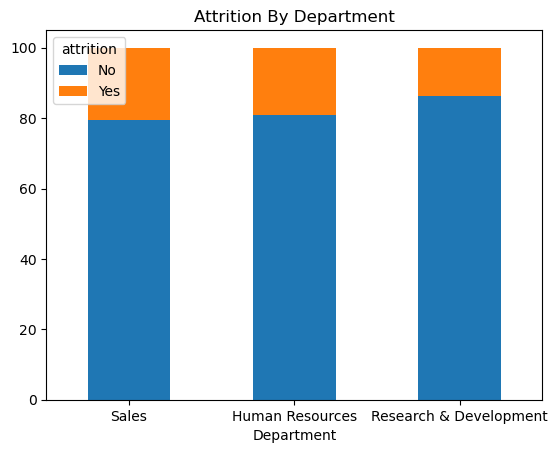

In [182]:
dep = pd.crosstab(df['department'], df['attrition'], normalize='index') * 100

dep = dep.sort_values(by='Yes', ascending=False)

dep.plot(
    kind='bar',
    stacked=True
)
plt.title('Attrition By Department')
plt.xlabel('Department')

plt.xticks(rotation=0)
plt.show()


# Overtime VS Attrition

In [61]:
overtime_attrition = ( 

df.groupby('overtime')['attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
      .round(1)
)
overtime_attrition

overtime
Yes    30.5
No     10.4
Name: attrition, dtype: float64

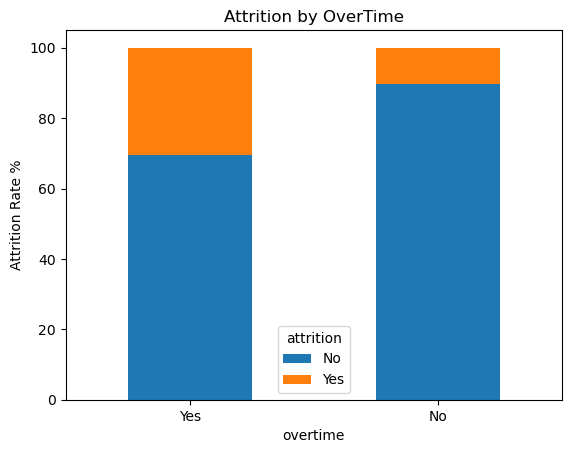

In [187]:
ovt = pd.crosstab(df['overtime'], df['attrition'], normalize='index') * 100

ovt = ovt.sort_values(by='Yes', ascending=False)

ovt.plot(
    kind='bar',
    stacked=True
)
plt.title('Attrition by OverTime')
plt.ylabel('Attrition Rate %')

plt.xticks(rotation=0)
plt.show()


# Attrition By AgeGroup

In [127]:
bins = [18, 25, 35, 45, 55, 65]
labels = ['Under 25', '26-35', '36-45', '46-55', '56-65']

df['AgeGroup'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)


In [167]:
age_attrition = (
    df.groupby('AgeGroup', observed=True)['attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='Attrition_Rate')
)
age_attrition = age_attrition.sort_values('Attrition_Rate', ascending=False)


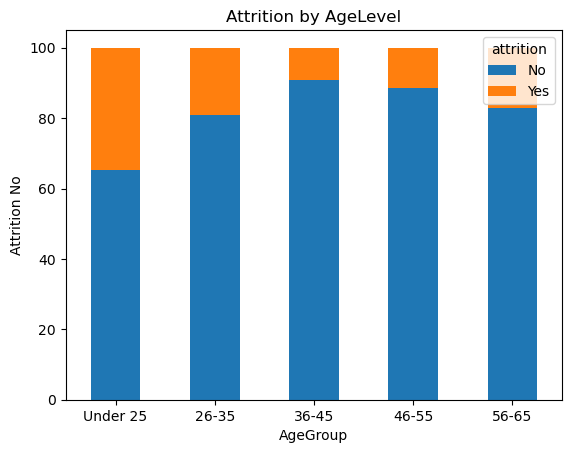

In [186]:
age = pd.crosstab(df['AgeGroup'], df['attrition'], normalize='index') * 100

Aga = age.sort_values(by='Yes', ascending=False)

age.plot(
    kind='bar',
    stacked=True
)
plt.title('Attrition by AgeLevel')
plt.ylabel('Attrition No')

plt.xticks(rotation=0)
plt.show()


# Monthly Income: Churned vs Stayed

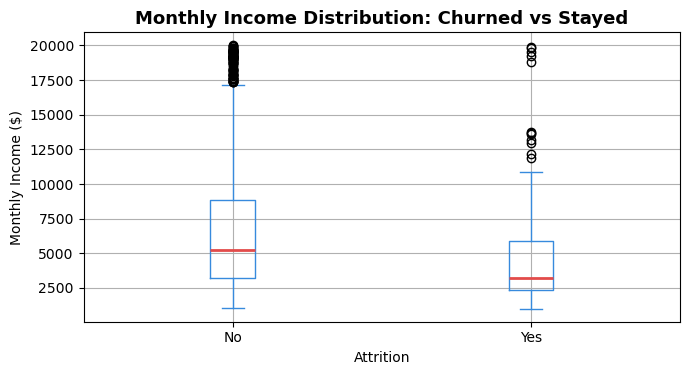

In [85]:
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='monthlyincome', by='attrition', ax=ax,
           boxprops=dict(color='#378ADD'),
           medianprops=dict(color='#E24B4A', linewidth=2),
           whiskerprops=dict(color='#378ADD'),
           capprops=dict(color='#378ADD'))
ax.set_title('Monthly Income Distribution: Churned vs Stayed', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition')
ax.set_ylabel('Monthly Income ($)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('chart4_income.png', dpi=150, bbox_inches='tight')
plt.show()

In [175]:
income_attrition = (
    df.groupby('income_band')['attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .reset_index(name='Attrition_Rate')
)
income_attrition = income_attrition.sort_values('Attrition_Rate', ascending=False)
income_attrition

,income_band,Attrition_Rate
1,Low,28.607595
2,Meduim,12.031250
0,High,10.804598


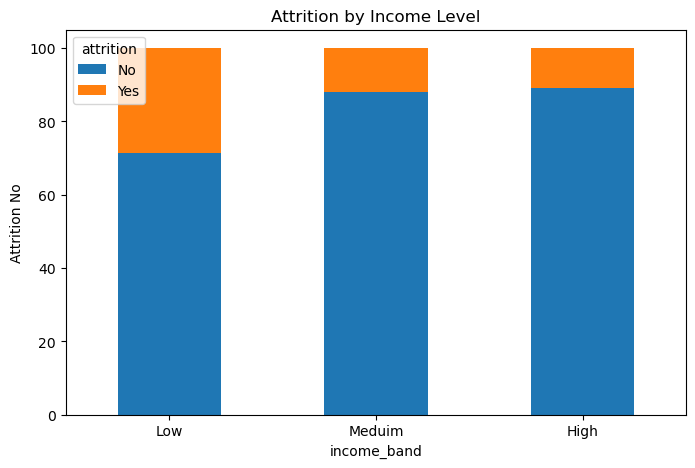

In [185]:
income = pd.crosstab(df['income_band'], df['attrition'], normalize='index') * 100

income = mohamed.sort_values(by='Yes', ascending=False)

income.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)
plt.title('Attrition by Income Level')
plt.ylabel('Attrition No')
plt.xticks(rotation=0)
plt.show()


# Correlation Heatmap

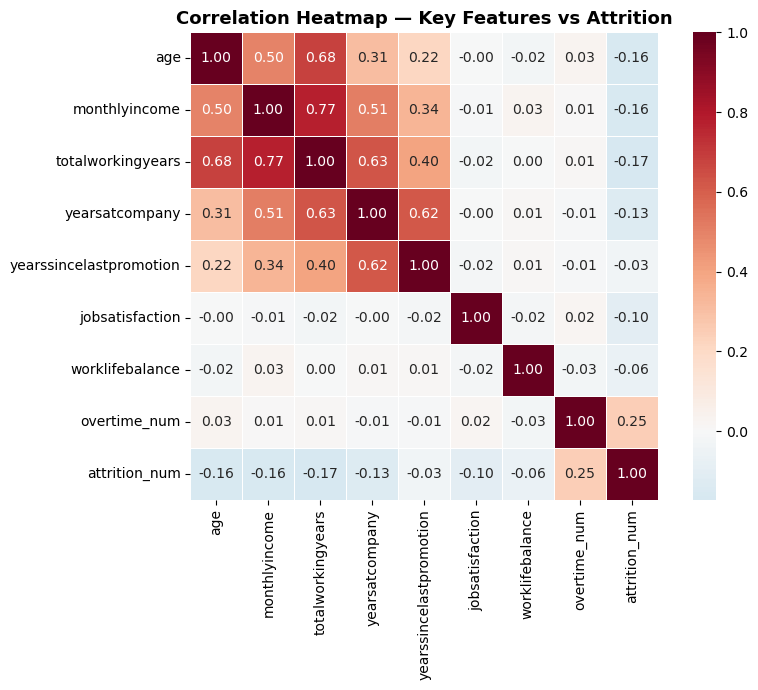

In [179]:
num_cols = ['age','monthlyincome','totalworkingyears','yearsatcompany',
            'yearssincelastpromotion','jobsatisfaction','worklifebalance',
            'overtime' if 'overtime' not in df.select_dtypes(include='number').columns else 'overtime',
            'attrition_num']

df['overtime_num'] = (df['overtime'] == 'Yes').astype(int)
cols = ['age','monthlyincome','totalworkingyears','yearsatcompany',
        'yearssincelastpromotion','jobsatisfaction','worklifebalance','overtime_num','attrition_num']

corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Key Features vs Attrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [188]:
df.to_csv("HR_cleaned_for_vigualization.csv", index=False)

print("Cleaned file created: HR_cleaned_for_vigualization.csv")

Cleaned file created: HR_cleaned_for_vigualization.csv
